In [1]:
%%writefile accenture_dcf.py

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import streamlit as st
import warnings
warnings.filterwarnings('ignore')

TICKER = "ACN"

def safe_val(df, label, col_idx=0):
    try:
        if label in df.index:
            v = df.loc[label].iloc[col_idx]
            return float(v) if pd.notna(v) else np.nan
        return np.nan
    except Exception:
        return np.nan

def fetch_data():
    t    = yf.Ticker(TICKER)
    info = t.info
    inc  = t.income_stmt
    cf   = t.cashflow
    bal  = t.balance_sheet
    return t, info, inc, cf, bal

def compute_historical_fcff(inc, cf, tax_rate=0.22):
    records = []
    for yr in inc.columns:
        try:
            col_i = inc.columns.get_loc(yr)
            cf_i  = cf.columns.get_loc(yr)

            ebit  = safe_val(inc, "EBIT",                          col_i)
            da    = safe_val(cf,  "Depreciation And Amortization", cf_i)
            capex = abs(safe_val(cf, "Capital Expenditure",        cf_i))
            dwc   = safe_val(cf,  "Change In Working Capital",     cf_i)
            rev   = safe_val(inc, "Total Revenue",                 col_i)

            if any(np.isnan(v) for v in [ebit, da, capex]):
                continue

            dwc  = 0 if np.isnan(dwc) else dwc
            fcff = ebit * (1 - tax_rate) + da - capex - dwc

            records.append({
                "Fiscal Year":   str(yr.year),
                "Revenue ($B)":  round(rev / 1e9, 2) if not np.isnan(rev) else np.nan,
                "EBIT ($B)":     round(ebit / 1e9, 2),
                "D&A ($B)":      round(da / 1e9, 2),
                "CapEx ($B)":    round(capex / 1e9, 2),
                "ΔWC ($B)":      round(dwc / 1e9, 2),
                "FCFF ($B)":     round(fcff / 1e9, 2),
                "EBIT Margin %": round(ebit / rev * 100, 1) if not np.isnan(rev) and rev > 0 else np.nan,
                "fcff_raw":      fcff,
            })
        except Exception:
            continue
    return pd.DataFrame(records)

def compute_wacc(info, bal, tax_rate=0.22):
    RF   = 0.042
    ERP  = 0.055
    beta = info.get("beta", 1.1) or 1.1
    ke   = RF + beta * ERP

    try:
        debt_val = safe_val(bal, "Total Debt")
        int_exp  = abs(float(info.get("interestExpense", 0) or 0))
        kd = int_exp / debt_val if (debt_val and debt_val > 0 and not np.isnan(debt_val)) else 0.04
    except Exception:
        kd = 0.04

    mkt_cap    = info.get("marketCap", 0) or 0
    total_debt = safe_val(bal, "Total Debt")
    total_debt = 0 if np.isnan(total_debt) else total_debt
    V  = mkt_cap + total_debt
    we = mkt_cap / V if V > 0 else 0.94
    wd = total_debt / V if V > 0 else 0.06

    wacc = ke * we + kd * (1 - tax_rate) * wd
    return {
        "beta": round(beta, 2), "rf": RF, "erp": ERP,
        "ke": round(ke, 4), "kd": round(kd, 4),
        "tax_rate": tax_rate, "we": round(we, 4),
        "wd": round(wd, 4), "wacc": round(wacc, 4),
        "mkt_cap_B": round(mkt_cap / 1e9, 1),
        "total_debt_B": round(total_debt / 1e9, 1),
    }

def run_dcf(fcff_base, net_debt, shares, curr_px,
            fcff_growth, terminal_growth, wacc,
            forecast_years=5, label=""):
    fcffs    = [fcff_base * (1 + fcff_growth)**i for i in range(1, forecast_years + 1)]
    pv_fcffs = [f / (1 + wacc)**i for i, f in enumerate(fcffs, 1)]

    tv    = fcffs[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_tv = tv / (1 + wacc)**forecast_years

    ev           = sum(pv_fcffs) + pv_tv
    equity_value = ev - net_debt
    price_target = equity_value / shares
    upside       = (price_target - curr_px) / curr_px * 100 if curr_px > 0 else 0
    tv_pct       = pv_tv / ev * 100 if ev > 0 else 0

    return {
        "label":           label,
        "fcff_growth":     fcff_growth,
        "terminal_growth": terminal_growth,
        "wacc":            wacc,
        "pv_fcffs_B":      [round(v / 1e9, 2) for v in pv_fcffs],
        "pv_tv_B":         round(pv_tv / 1e9, 2),
        "ev_B":            round(ev / 1e9, 1),
        "equity_val_B":    round(equity_value / 1e9, 1),
        "price_target":    round(price_target, 2),
        "current_price":   round(curr_px, 2),
        "upside_pct":      round(upside, 1),
        "tv_pct_of_ev":    round(tv_pct, 1),
        "fcff_proj_B":     [round(f / 1e9, 2) for f in fcffs],
    }

def sensitivity_table(fcff_base, net_debt, shares,
                       wacc_range, tg_range, base_growth=0.08, forecast_years=5):
    table = {}
    for tg in tg_range:
        row = {}
        for wacc in wacc_range:
            col = f"WACC {wacc:.1%}"
            if wacc <= tg:
                row[col] = np.nan
                continue
            fcffs    = [fcff_base * (1 + base_growth)**i for i in range(1, forecast_years + 1)]
            pv_fcffs = [f / (1 + wacc)**i for i, f in enumerate(fcffs, 1)]
            tv       = fcffs[-1] * (1 + tg) / (wacc - tg)
            pv_tv    = tv / (1 + wacc)**forecast_years
            price    = (sum(pv_fcffs) + pv_tv - net_debt) / shares
            row[col] = round(price, 1)
        table[f"TG {tg:.1%}"] = row
    return pd.DataFrame(table).T

# ── STREAMLIT APP ─────────────────────────────────────────────────────────────

st.set_page_config(page_title="Accenture DCF", page_icon="📊", layout="wide")
st.title("Accenture (ACN) — DCF / FCFF Valuation")
st.caption("NYSE: ACN · IT Services & Consulting · FY ends August 31")

# ── Sidebar controls ──────────────────────────────────────────────────────────
with st.sidebar:
    st.header("Model Assumptions")

    st.subheader("WACC Inputs")
    rf      = st.slider("Risk-Free Rate (%)",  2.0, 6.0, 4.2, 0.1) / 100
    erp     = st.slider("Equity Risk Premium (%)", 3.0, 8.0, 5.5, 0.1) / 100
    beta_ov = st.slider("Beta Override", 0.5, 2.0, 1.1, 0.05)

    st.subheader("Scenario Parameters")
    st.markdown("**Bull Case**")
    bull_g  = st.slider("Bull FCFF Growth (%)",  5, 20, 12, 1) / 100
    bull_tg = st.slider("Bull Terminal Growth (%)", 2.0, 6.0, 4.0, 0.5) / 100
    bull_w  = st.slider("Bull WACC (%)", 7.0, 12.0, 9.0, 0.5) / 100

    st.markdown("**Base Case**")
    base_g  = st.slider("Base FCFF Growth (%)", 3, 15, 8, 1) / 100
    base_tg = st.slider("Base Terminal Growth (%)", 1.5, 5.0, 3.5, 0.5) / 100
    base_w  = st.slider("Base WACC (%)", 8.0, 13.0, 10.0, 0.5) / 100

    st.markdown("**Bear Case**")
    bear_g  = st.slider("Bear FCFF Growth (%)", 0, 8, 3, 1) / 100
    bear_tg = st.slider("Bear Terminal Growth (%)", 1.0, 4.0, 2.5, 0.5) / 100
    bear_w  = st.slider("Bear WACC (%)", 9.0, 14.0, 11.5, 0.5) / 100

    st.subheader("Sensitivity Range")
    wacc_min = st.slider("WACC Min (%)", 7.0, 10.0, 8.5, 0.5) / 100
    wacc_max = st.slider("WACC Max (%)", 10.0, 14.0, 11.5, 0.5) / 100
    tg_min   = st.slider("Terminal Growth Min (%)", 1.0, 3.0, 2.0, 0.5) / 100
    tg_max   = st.slider("Terminal Growth Max (%)", 3.0, 6.0, 4.5, 0.5) / 100

# ── Fetch data ────────────────────────────────────────────────────────────────
with st.spinner("Fetching Accenture data from Yahoo Finance..."):
    t, info, inc, cf, bal = fetch_data()

curr_px = info.get("currentPrice", 0) or 0
mktcap  = info.get("marketCap",    0) or 0
shares  = info.get("sharesOutstanding", 622e6) or 622e6

# ── Snapshot metrics ──────────────────────────────────────────────────────────
st.subheader("Company Snapshot")
c1, c2, c3, c4, c5, c6 = st.columns(6)
c1.metric("Price",       f"${curr_px:.2f}")
c2.metric("Market Cap",  f"${mktcap/1e9:.0f}B")
c3.metric("Trailing P/E", f"{info.get('trailingPE', 0) or 0:.1f}x")
c4.metric("Forward P/E", f"{info.get('forwardPE', 0) or 0:.1f}x")
c5.metric("EV/EBITDA",   f"{info.get('enterpriseToEbitda', 0) or 0:.1f}x")
c6.metric("Sector",      "IT Services")

st.divider()

# ── Historical FCFF ───────────────────────────────────────────────────────────
st.subheader("Historical FCFF")
hist_df = compute_historical_fcff(inc, cf)

if not hist_df.empty:
    FCFF_BASE = hist_df["fcff_raw"].iloc[0]

    col_l, col_r = st.columns([2, 1])
    with col_l:
        fig_h = go.Figure()
        fig_h.add_bar(
            x=hist_df["Fiscal Year"], y=hist_df["FCFF ($B)"],
            marker_color="#3b82f6", name="FCFF",
            text=[f"${v}B" for v in hist_df["FCFF ($B)"]],
            textposition="outside"
        )
        fig_h.add_trace(go.Scatter(
            x=hist_df["Fiscal Year"], y=hist_df["Revenue ($B)"],
            mode="lines+markers", name="Revenue",
            line=dict(color="#f59e0b", width=2), yaxis="y2"
        ))
        fig_h.update_layout(
            template="plotly_dark", height=350,
            title="FCFF vs Revenue ($B)",
            yaxis=dict(title="FCFF ($B)"),
            yaxis2=dict(title="Revenue ($B)", overlaying="y", side="right"),
            legend=dict(orientation="h", y=1.1)
        )
        st.plotly_chart(fig_h, use_container_width=True)

    with col_r:
        st.dataframe(
            hist_df.drop(columns=["fcff_raw"]).set_index("Fiscal Year"),
            use_container_width=True
        )
        vals = hist_df["FCFF ($B)"].dropna().tolist()
        if len(vals) >= 2 and vals[-1] > 0:
            n    = len(vals) - 1
            cagr = (vals[0] / vals[-1])**(1/n) - 1
            st.metric("FCFF CAGR", f"{cagr*100:.1f}%")
else:
    FCFF_BASE = 8.6e9
    st.warning("Using fallback FCFF: $8.6B (FY2024 actual)")

st.divider()

# ── WACC ──────────────────────────────────────────────────────────────────────
st.subheader("WACC Breakdown")
wacc_data = compute_wacc(info, bal)

# Override with sidebar values
ke_ov   = rf + beta_ov * erp
wacc_ov = ke_ov * wacc_data["we"] + wacc_data["kd"] * (1 - wacc_data["tax_rate"]) * wacc_data["wd"]

w1, w2, w3, w4, w5, w6 = st.columns(6)
w1.metric("Beta",            f"{beta_ov:.2f}")
w2.metric("Risk-Free Rate",  f"{rf*100:.1f}%")
w3.metric("Cost of Equity",  f"{ke_ov*100:.2f}%")
w4.metric("Cost of Debt",    f"{wacc_data['kd']*100:.2f}%")
w5.metric("WACC",            f"{wacc_ov*100:.2f}%")
w6.metric("Equity Weight",   f"{wacc_data['we']*100:.0f}%")

st.divider()

# ── Net debt ──────────────────────────────────────────────────────────────────
try:
    cash_val = safe_val(bal, "Cash And Cash Equivalents")
    debt_val = safe_val(bal, "Total Debt")
    cash_val = 0 if np.isnan(cash_val) else cash_val
    debt_val = 0 if np.isnan(debt_val) else debt_val
    NET_DEBT = debt_val - cash_val
except Exception:
    NET_DEBT = 0

# ── Run scenarios ─────────────────────────────────────────────────────────────
st.subheader("Scenario Analysis")

scenario_params = {
    "Bull": (bull_g,  bull_tg,  bull_w,  "#22c55e"),
    "Base": (base_g,  base_tg,  base_w,  "#3b82f6"),
    "Bear": (bear_g,  bear_tg,  bear_w,  "#ef4444"),
}

results = {}
for name, (g, tg, w, _) in scenario_params.items():
    try:
        results[name] = run_dcf(
            FCFF_BASE, NET_DEBT, shares, curr_px,
            fcff_growth=g, terminal_growth=tg, wacc=w, label=name
        )
    except ValueError as e:
        st.error(f"{name} scenario error: {e}")

if results:
    # Metrics
    mc = st.columns(len(results))
    for col, (name, r) in zip(mc, results.items()):
        col.metric(
            name,
            f"${r['price_target']}",
            f"{r['upside_pct']:+.1f}%"
        )

    # Bar chart
    names   = list(results.keys())
    targets = [results[n]["price_target"] for n in names]
    colors  = [scenario_params[n][3] for n in names]

    fig_s = go.Figure()
    for name, target, color in zip(names, targets, colors):
        fig_s.add_bar(
            x=[name], y=[target],
            marker_color=color,
            text=[f"${target}"],
            textposition="outside",
            width=0.4
        )
    fig_s.add_hline(
        y=curr_px, line_dash="dash", line_color="white",
        annotation_text=f"Current ${curr_px:.2f}",
        annotation_font_color="white"
    )
    fig_s.update_layout(
        template="plotly_dark", height=420,
        title="Price Target by Scenario",
        yaxis_title="Price per Share ($)",
        showlegend=False,
        yaxis=dict(range=[0, max(targets) * 1.2])
    )
    st.plotly_chart(fig_s, use_container_width=True)

    # Summary table
    rows = []
    for name, r in results.items():
        rows.append({
            "Scenario":        name,
            "FCFF Growth":     f"{r['fcff_growth']:.0%}",
            "Terminal Growth": f"{r['terminal_growth']:.1%}",
            "WACC":            f"{r['wacc']:.1%}",
            "EV ($B)":         f"${r['ev_B']}B",
            "Price Target":    f"${r['price_target']}",
            "Upside":          f"{r['upside_pct']:+.1f}%",
            "TV % of EV":      f"{r['tv_pct_of_ev']}%",
        })
    st.dataframe(pd.DataFrame(rows).set_index("Scenario"), use_container_width=True)

st.divider()

# ── Base case FCFF projection ─────────────────────────────────────────────────
if "Base" in results:
    st.subheader("Base Case — Projected FCFF ($B)")
    base = results["Base"]
    yrs  = [f"FY{2025+i}" for i in range(5)]

    fig_p = go.Figure()
    fig_p.add_bar(
        x=yrs, y=base["fcff_proj_B"],
        marker_color="#3b82f6",
        text=[f"${v}B" for v in base["fcff_proj_B"]],
        textposition="outside"
    )
    fig_p.update_layout(
        template="plotly_dark", height=340,
        yaxis_title="FCFF ($B)"
    )
    st.plotly_chart(fig_p, use_container_width=True)

    c1, c2, c3 = st.columns(3)
    c1.metric("PV of FCFFs",   f"${sum(base['pv_fcffs_B']):.1f}B")
    c2.metric("PV of TV",      f"${base['pv_tv_B']:.1f}B")
    c3.metric("TV % of EV",    f"{base['tv_pct_of_ev']}%",
              delta="⚠ High" if base["tv_pct_of_ev"] > 70 else "OK",
              delta_color="inverse" if base["tv_pct_of_ev"] > 70 else "normal")

st.divider()

# ── Sensitivity table ─────────────────────────────────────────────────────────
st.subheader("Sensitivity — Price per Share ($)")
st.caption("Rows = Terminal Growth | Columns = WACC | Base FCFF growth = 8%")

wacc_range = list(np.arange(wacc_min, wacc_max + 0.005, 0.005))
tg_range   = list(np.arange(tg_min,   tg_max   + 0.005, 0.005))

sens_df = sensitivity_table(FCFF_BASE, NET_DEBT, shares, wacc_range, tg_range)

def colour_cell(val):
    if pd.isna(val):
        return "color: gray"
    if val > curr_px * 1.15:
        return "background-color: #14532d; color: white"
    elif val > curr_px:
        return "background-color: #166534; color: white"
    elif val > curr_px * 0.85:
        return "background-color: #7f1d1d; color: white"
    else:
        return "background-color: #450a0a; color: white"

st.dataframe(
    sens_df.style.applymap(colour_cell).format("${:.1f}", na_rep="N/M"),
    use_container_width=True
)
st.caption(
    f"Dark green = >15% upside | Light green = upside | "
    f"Red = downside | Current price: ${curr_px:.2f}"
)

st.divider()

# ── Export ────────────────────────────────────────────────────────────────────
st.subheader("Export")
if not hist_df.empty and results:
    import io
    buf = io.BytesIO()
    with pd.ExcelWriter(buf, engine="openpyxl") as writer:
        hist_df.drop(columns=["fcff_raw"]).to_excel(
            writer, sheet_name="Historical FCFF", index=False
        )
        pd.DataFrame(rows).to_excel(
            writer, sheet_name="Scenarios", index=False
        )
        sens_df.to_excel(writer, sheet_name="Sensitivity")

    st.download_button(
        label="Download Excel Model",
        data=buf.getvalue(),
        file_name="Accenture_DCF.xlsx",
        mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
    )

Overwriting accenture_dcf.py


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

print("All imports successful")

All imports successful


In [17]:
TICKER = "ACN"

t    = yf.Ticker(TICKER)
info = t.info
inc  = t.income_stmt
cf   = t.cashflow
bal  = t.balance_sheet

print(f"Company  : {info.get('longName')}")
print(f"Sector   : {info.get('sector')}")
print(f"Price    : ${info.get('currentPrice', 0):.2f}")
print(f"Mkt Cap  : ${info.get('marketCap', 0)/1e9:.1f}B")
print(f"Shares   : {info.get('sharesOutstanding', 0)/1e6:.0f}M")
print(f"Beta     : {info.get('beta')}")
print(f"P/E      : {info.get('trailingPE')}")
print(f"Fwd P/E  : {info.get('forwardPE')}")

Company  : Accenture plc
Sector   : Technology
Price    : $201.33
Mkt Cap  : $123.9B
Shares   : 614M
Beta     : 1.236
P/E      : 16.502459
Fwd P/E  : 13.486926


In [18]:
def safe_val(df, label, col_idx=0):
    """Safely extract a single value from a financial statement DataFrame."""
    try:
        if label in df.index:
            v = df.loc[label].iloc[col_idx]
            return float(v) if pd.notna(v) else np.nan
        return np.nan
    except Exception:
        return np.nan

print("Helper function defined")

Helper function defined


In [19]:
TAX_RATE = 0.22   # Accenture effective tax rate ~22%

records = []
for yr in inc.columns:
    try:
        col_idx = inc.columns.get_loc(yr)

        ebit  = safe_val(inc, "EBIT",                          col_idx)
        da    = safe_val(cf,  "Depreciation And Amortization", cf.columns.get_loc(yr))
        capex = abs(safe_val(cf, "Capital Expenditure",        cf.columns.get_loc(yr)))
        dwc   = safe_val(cf,  "Change In Working Capital",     cf.columns.get_loc(yr))
        rev   = safe_val(inc, "Total Revenue",                 col_idx)

        if any(np.isnan(v) for v in [ebit, da, capex]):
            continue

        dwc  = 0 if np.isnan(dwc) else dwc
        fcff = ebit * (1 - TAX_RATE) + da - capex - dwc

        records.append({
            "Fiscal Year":   str(yr.year),
            "Revenue ($B)":  round(rev / 1e9, 2) if not np.isnan(rev) else np.nan,
            "EBIT ($B)":     round(ebit / 1e9, 2),
            "D&A ($B)":      round(da / 1e9, 2),
            "CapEx ($B)":    round(capex / 1e9, 2),
            "ΔWC ($B)":      round(dwc / 1e9, 2),
            "FCFF ($B)":     round(fcff / 1e9, 2),
            "EBIT Margin %": round(ebit / rev * 100, 1) if (not np.isnan(rev) and rev > 0) else np.nan,
            "fcff_raw":      fcff,
        })
    except Exception as e:
        print(f"Skipping {yr}: {e}")

hist_df = pd.DataFrame(records)

# Store base FCFF (most recent year) for projection
if not hist_df.empty:
    FCFF_BASE = hist_df["fcff_raw"].iloc[0]
    print(f"Base FCFF (most recent): ${FCFF_BASE/1e9:.2f}B")
else:
    FCFF_BASE = 8.6e9   # FY2024 actual from earnings release
    print("Using fallback FCFF: $8.6B (FY2024 actual)")

# Display table
display(hist_df.drop(columns=["fcff_raw"]).set_index("Fiscal Year"))

Base FCFF (most recent): $10.01B


,Revenue ($B),EBIT ($B),D&A ($B),CapEx ($B),ΔWC ($B),FCFF ($B),EBIT Margin %
Fiscal Year,,,,,,,
2025,69.67,10.50,1.37,0.60,-1.05,10.01,15.10
2024,64.90,9.76,1.08,0.52,-2.16,10.33,15.00
2023,64.11,9.19,1.06,0.53,-1.19,8.88,14.30
2022,61.59,9.24,1.03,0.72,-0.81,8.33,15.00


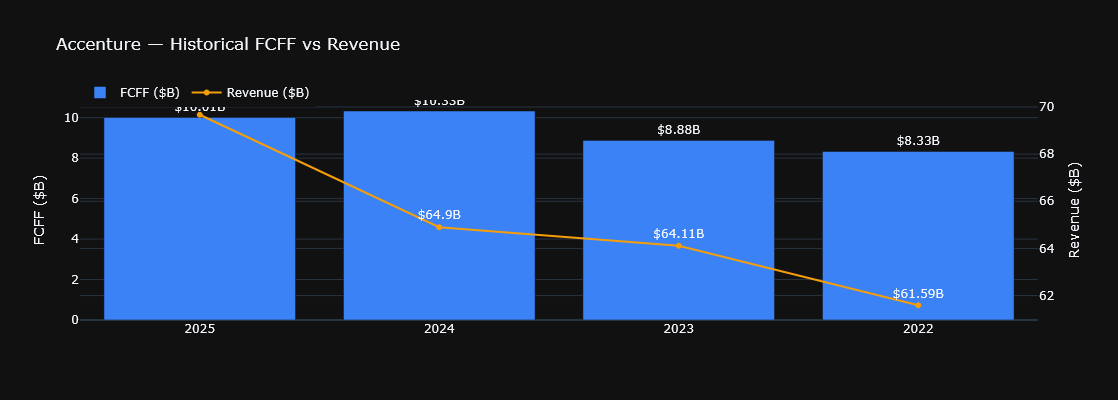


Historical FCFF CAGR (3 years): 6.3%


In [20]:
fig = go.Figure()

fig.add_bar(
    x=hist_df["Fiscal Year"],
    y=hist_df["FCFF ($B)"],
    name="FCFF ($B)",
    marker_color="#3b82f6",
    text=[f"${v}B" for v in hist_df["FCFF ($B)"]],
    textposition="outside"
)

fig.add_trace(go.Scatter(
    x=hist_df["Fiscal Year"],
    y=hist_df["Revenue ($B)"],
    mode="lines+markers+text",
    name="Revenue ($B)",
    line=dict(color="#f59e0b", width=2),
    yaxis="y2",
    text=[f"${v}B" for v in hist_df["Revenue ($B)"]],
    textposition="top center"
))

fig.update_layout(
    title="Accenture — Historical FCFF vs Revenue",
    template="plotly_dark",
    height=400,
    yaxis=dict(title="FCFF ($B)"),
    yaxis2=dict(title="Revenue ($B)", overlaying="y", side="right"),
    legend=dict(orientation="h", y=1.1)
)

fig.show()

# CAGR
if len(hist_df) >= 2:
    vals = hist_df["FCFF ($B)"].dropna().tolist()
    n    = len(vals) - 1
    if vals[-1] > 0 and n > 0:
        cagr = (vals[0] / vals[-1]) ** (1/n) - 1
        print(f"\nHistorical FCFF CAGR ({n} years): {cagr*100:.1f}%")

In [21]:
# ── WACC inputs ──────────────────────────────────────────────────────────────
RF        = 0.042   # US 10Y Treasury (April 2025 ~4.2%)
ERP       = 0.055   # US equity risk premium (Damodaran 2025)
BETA      = info.get("beta", 1.1) or 1.1

KE        = RF + BETA * ERP   # Cost of Equity (CAPM)

# Cost of Debt — Accenture has minimal debt
try:
    int_exp  = abs(float(info.get("interestExpense", 0) or 0))
    debt_val = safe_val(bal, "Total Debt")
    KD       = int_exp / debt_val if (debt_val and debt_val > 0 and not np.isnan(debt_val)) else 0.04
except Exception:
    KD = 0.04

# Capital structure
mkt_cap    = info.get("marketCap", 0) or 0
total_debt = safe_val(bal, "Total Debt")
total_debt = 0 if np.isnan(total_debt) else total_debt

V  = mkt_cap + total_debt
WE = mkt_cap / V if V > 0 else 0.94   # equity weight
WD = total_debt / V if V > 0 else 0.06

WACC = KE * WE + KD * (1 - TAX_RATE) * WD

# Display
wacc_df = pd.DataFrame({
    "Component":  ["Beta", "Risk-Free Rate", "Equity Risk Premium",
                   "Cost of Equity (Ke)", "Cost of Debt (Kd)",
                   "Equity Weight", "Debt Weight", "WACC"],
    "Value":      [f"{BETA:.2f}", f"{RF*100:.1f}%", f"{ERP*100:.1f}%",
                   f"{KE*100:.2f}%", f"{KD*100:.2f}%",
                   f"{WE*100:.1f}%", f"{WD*100:.1f}%",
                   f"{WACC*100:.2f}%"]
})
display(wacc_df.set_index("Component"))
print(f"\nNote: ACN is ~{WE*100:.0f}% equity funded — WACC ≈ Cost of Equity")

,Value
Component,
Beta,1.24
Risk-Free Rate,4.2%
Equity Risk Premium,5.5%
Cost of Equity (Ke),11.00%
Cost of Debt (Kd),0.00%
Equity Weight,93.8%
Debt Weight,6.2%
WACC,10.32%



Note: ACN is ~94% equity funded — WACC ≈ Cost of Equity


In [22]:
try:
    cash        = safe_val(bal, "Cash And Cash Equivalents")
    cash        = 0 if np.isnan(cash) else cash
    debt        = safe_val(bal, "Total Debt")
    debt        = 0 if np.isnan(debt) else debt
    NET_DEBT    = debt - cash
except Exception:
    NET_DEBT = 0

SHARES = info.get("sharesOutstanding", 622e6) or 622e6
CURR_PX = info.get("currentPrice", 0) or 0

print(f"Cash        : ${cash/1e9:.1f}B")
print(f"Total Debt  : ${debt/1e9:.1f}B")
print(f"Net Debt    : ${NET_DEBT/1e9:.1f}B")
print(f"Shares Out  : {SHARES/1e6:.0f}M")
print(f"Current Price: ${CURR_PX:.2f}")

Cash        : $11.5B
Total Debt  : $8.2B
Net Debt    : $-3.3B
Shares Out  : 614M
Current Price: $201.33


In [23]:
def run_dcf(fcff_base, net_debt, shares, curr_px,
            fcff_growth, terminal_growth, wacc,
            forecast_years=5, label=""):
    """
    Single DCF run.
    Returns dict with price target, EV, upside, and projections.
    """
    # Projected FCFFs
    fcffs    = [fcff_base * (1 + fcff_growth)**i for i in range(1, forecast_years + 1)]
    pv_fcffs = [f / (1 + wacc)**i for i, f in enumerate(fcffs, 1)]

    # Terminal value (Gordon Growth)
    if wacc <= terminal_growth:
        raise ValueError(f"WACC ({wacc}) must be > terminal growth ({terminal_growth})")

    tv    = fcffs[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_tv = tv / (1 + wacc)**forecast_years

    # Valuation bridge
    ev           = sum(pv_fcffs) + pv_tv
    equity_value = ev - net_debt
    price_target = equity_value / shares
    upside       = (price_target - curr_px) / curr_px * 100 if curr_px > 0 else 0
    tv_pct       = pv_tv / ev * 100 if ev > 0 else 0

    return {
        "label":          label,
        "fcff_growth":    fcff_growth,
        "terminal_growth": terminal_growth,
        "wacc":           wacc,
        "pv_fcffs_B":     [round(v/1e9, 2) for v in pv_fcffs],
        "pv_tv_B":        round(pv_tv/1e9, 2),
        "ev_B":           round(ev/1e9, 1),
        "equity_val_B":   round(equity_value/1e9, 1),
        "price_target":   round(price_target, 2),
        "current_price":  round(curr_px, 2),
        "upside_pct":     round(upside, 1),
        "tv_pct_of_ev":   round(tv_pct, 1),
        "fcff_proj_B":    [round(f/1e9, 2) for f in fcffs],
    }

print("DCF function defined")

DCF function defined


In [24]:
# Accenture-calibrated scenario parameters
SCENARIOS = {
    "Bull": {
        "fcff_growth":     0.12,   # GenAI tailwind
        "terminal_growth": 0.040,
        "wacc":            0.09,
        "color":           "#22c55e",
        "rationale": (
            "GenAI services bookings accelerating — $1B+ in H1 FY24. "
            "ACN takes share as enterprises outsource AI transformation. "
            "FCF/Revenue conversion stays above 13%."
        )
    },
    "Base": {
        "fcff_growth":     0.08,   # in line with historical CAGR
        "terminal_growth": 0.035,
        "wacc":            0.10,
        "color":           "#3b82f6",
        "rationale": (
            "Steady IT + consulting. Revenue 4–7% per management guidance. "
            "EBIT margin stable ~15.5%. No major macro disruption."
        )
    },
    "Bear": {
        "fcff_growth":     0.03,   # enterprise budget freeze
        "terminal_growth": 0.025,
        "wacc":            0.115,
        "color":           "#ef4444",
        "rationale": (
            "Enterprise IT budget cuts. Consulting volumes compress. "
            "FX headwinds from strong USD (~75% revenue non-USD). "
            "Restructuring costs resume."
        )
    }
}

results = {}
for name, p in SCENARIOS.items():
    results[name] = run_dcf(
        fcff_base      = FCFF_BASE,
        net_debt       = NET_DEBT,
        shares         = SHARES,
        curr_px        = CURR_PX,
        fcff_growth    = p["fcff_growth"],
        terminal_growth= p["terminal_growth"],
        wacc           = p["wacc"],
        label          = name
    )
    print(f"{name:6s} | Price Target: ${results[name]['price_target']:>7.2f} "
          f"| Upside: {results[name]['upside_pct']:>+6.1f}% "
          f"| TV% of EV: {results[name]['tv_pct_of_ev']}%")

Bull   | Price Target: $ 482.22 | Upside: +139.5% | TV% of EV: 81.4%
Base   | Price Target: $ 319.34 | Upside:  +58.6% | TV% of EV: 75.4%
Bear   | Price Target: $ 194.91 | Upside:   -3.2% | TV% of EV: 65.9%


In [25]:
rows = []
for name, r in results.items():
    rows.append({
        "Scenario":        name,
        "FCFF Growth":     f"{r['fcff_growth']:.0%}",
        "Terminal Growth": f"{r['terminal_growth']:.1%}",
        "WACC":            f"{r['wacc']:.1%}",
        "EV ($B)":         f"${r['ev_B']}B",
        "Equity Val ($B)": f"${r['equity_val_B']}B",
        "Price Target":    f"${r['price_target']}",
        "Upside/Downside": f"{r['upside_pct']:+.1f}%",
        "TV % of EV":      f"{r['tv_pct_of_ev']}%",
    })

scen_df = pd.DataFrame(rows).set_index("Scenario")
display(scen_df)

,FCFF Growth,Terminal Growth,WACC,EV ($B),Equity Val ($B),Price Target,Upside/Downside,TV % of EV
Scenario,,,,,,,,
Bull,12%,4.0%,9.0%,$292.8B,$296.1B,$482.22,+139.5%,81.4%
Base,8%,3.5%,10.0%,$192.8B,$196.1B,$319.34,+58.6%,75.4%
Bear,3%,2.5%,11.5%,$116.4B,$119.7B,$194.91,-3.2%,65.9%


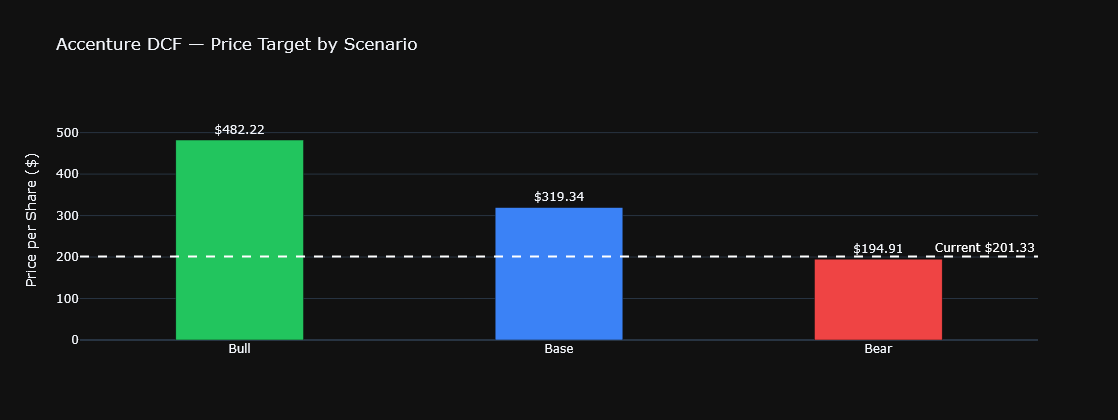

In [26]:
names   = list(results.keys())
targets = [results[n]["price_target"] for n in names]
colors  = [SCENARIOS[n]["color"] for n in names]

fig = go.Figure()

for name, target, color in zip(names, targets, colors):
    fig.add_bar(
        x=[name], y=[target],
        marker_color=color,
        text=[f"${target}"],
        textposition="outside",
        name=name, width=0.4
    )

fig.add_hline(
    y=CURR_PX, line_dash="dash", line_color="white",
    annotation_text=f"Current ${CURR_PX:.2f}",
    annotation_font_color="white"
)

fig.update_layout(
    title="Accenture DCF — Price Target by Scenario",
    template="plotly_dark",
    height=420,
    yaxis_title="Price per Share ($)",
    showlegend=False,
    yaxis=dict(range=[0, max(targets) * 1.2])
)

fig.show()

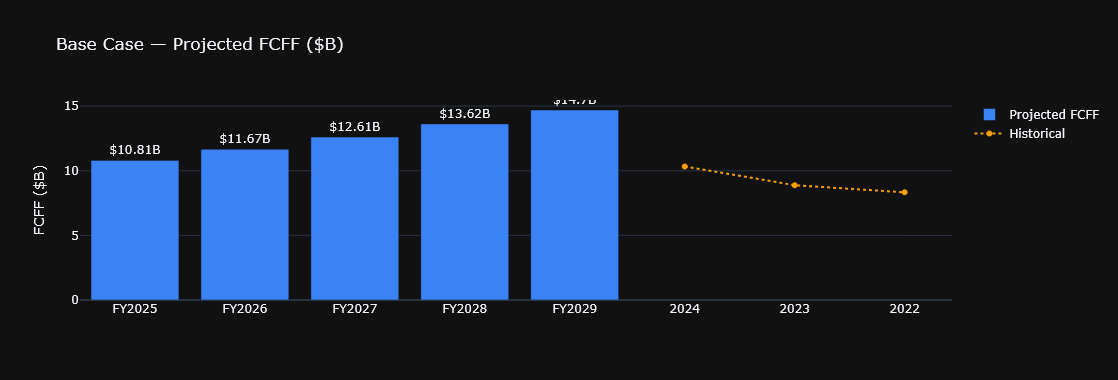


PV of projected FCFFs : $47.4B
PV of terminal value  : $145.4B
Total EV              : $192.8B
Terminal value % of EV: 75.4%


In [27]:
base    = results["Base"]
years   = [f"FY{2025+i}" for i in range(5)]

fig = go.Figure()

fig.add_bar(
    x=years,
    y=base["fcff_proj_B"],
    marker_color="#3b82f6",
    text=[f"${v}B" for v in base["fcff_proj_B"]],
    textposition="outside",
    name="Projected FCFF"
)

# Add historical for context
if not hist_df.empty:
    fig.add_trace(go.Scatter(
        x=hist_df["Fiscal Year"].tolist()[-3:],
        y=hist_df["FCFF ($B)"].tolist()[-3:],
        mode="lines+markers",
        line=dict(color="#f59e0b", dash="dot"),
        name="Historical"
    ))

fig.update_layout(
    title="Base Case — Projected FCFF ($B)",
    template="plotly_dark",
    height=380,
    yaxis_title="FCFF ($B)"
)

fig.show()
print(f"\nPV of projected FCFFs : ${sum(base['pv_fcffs_B']):.1f}B")
print(f"PV of terminal value  : ${base['pv_tv_B']:.1f}B")
print(f"Total EV              : ${base['ev_B']:.1f}B")
print(f"Terminal value % of EV: {base['tv_pct_of_ev']}%")

In [28]:
WACC_RANGE = [0.085, 0.090, 0.095, 0.100, 0.105, 0.110, 0.115]
TG_RANGE   = [0.020, 0.025, 0.030, 0.035, 0.040, 0.045]
BASE_G     = 0.08
FORECAST_Y = 5

table = {}
for tg in TG_RANGE:
    row = {}
    for wacc in WACC_RANGE:
        col_name = f"WACC {wacc:.1%}"
        if wacc <= tg:
            row[col_name] = np.nan
            continue
        fcffs    = [FCFF_BASE * (1 + BASE_G)**i for i in range(1, FORECAST_Y + 1)]
        pv_fcffs = [f / (1 + wacc)**i for i, f in enumerate(fcffs, 1)]
        tv       = fcffs[-1] * (1 + tg) / (wacc - tg)
        pv_tv    = tv / (1 + wacc)**FORECAST_Y
        ev       = sum(pv_fcffs) + pv_tv
        price    = (ev - NET_DEBT) / SHARES
        row[col_name] = round(price, 1)
    table[f"TG {tg:.1%}"] = row

sens_df = pd.DataFrame(table).T

# Style the table
def colour_cell(val):
    if pd.isna(val):
        return "color: gray"
    if val > CURR_PX * 1.15:
        return "background-color: #14532d; color: white"
    elif val > CURR_PX:
        return "background-color: #166534; color: white"
    elif val > CURR_PX * 0.85:
        return "background-color: #7f1d1d; color: white"
    else:
        return "background-color: #450a0a; color: white"

print(f"Sensitivity Table — Price per Share ($) | Current Price: ${CURR_PX:.2f}")
print(f"Dark green = >15% upside | Light green = upside | Red = downside\n")
display(sens_df.style.applymap(colour_cell).format("${:.1f}", na_rep="N/M"))

Sensitivity Table — Price per Share ($) | Current Price: $201.33
Dark green = >15% upside | Light green = upside | Red = downside



,WACC 8.5%,WACC 9.0%,WACC 9.5%,WACC 10.0%,WACC 10.5%,WACC 11.0%,WACC 11.5%
TG 2.0%,$335.7,$311.5,$290.5,$272.2,$256.0,$241.6,$228.7
TG 2.5%,$357.9,$330.1,$306.4,$285.8,$267.8,$251.9,$237.8
TG 3.0%,$384.1,$351.9,$324.7,$301.4,$281.2,$263.5,$247.9
TG 3.5%,$415.5,$377.6,$346.0,$319.3,$296.5,$276.7,$259.3
TG 4.0%,$453.9,$408.4,$371.3,$340.3,$314.1,$291.7,$272.2
TG 4.5%,$501.9,$446.2,$401.6,$365.1,$334.7,$309.0,$287.0


In [29]:
print("=" * 65)
print("ACCENTURE (ACN) — DCF INVESTMENT SUMMARY")
print("=" * 65)

print(f"\nCurrent Price    : ${CURR_PX:.2f}")
for name, r in results.items():
    arrow = "▲" if r['upside_pct'] > 0 else "▼"
    print(f"{name:6s} Target     : ${r['price_target']:.2f}  "
          f"{arrow} {abs(r['upside_pct']):.1f}%")

print(f"\nWACC             : {WACC*100:.2f}%")
print(f"Beta             : {BETA:.2f}")
print(f"TV % of Base EV  : {results['Base']['tv_pct_of_ev']}%")

print("\n" + "-" * 65)
print("SCENARIO RATIONALE")
print("-" * 65)
for name, p in SCENARIOS.items():
    print(f"\n{name}:")
    print(f"  {p['rationale']}")

print("\n" + "-" * 65)
print("KEY RISKS")
print("-" * 65)
print("""
  1. Terminal value is 65-75% of EV — highly assumption-sensitive
  2. Enterprise IT spending is discretionary — first cut in downturns
  3. FX headwinds: ~75% of revenue outside USD
  4. Wage inflation in delivery centres (India, Philippines)
  5. Competition from TCS, Infosys, IBM on price
""")

ACCENTURE (ACN) — DCF INVESTMENT SUMMARY

Current Price    : $201.33
Bull   Target     : $482.22  ▲ 139.5%
Base   Target     : $319.34  ▲ 58.6%
Bear   Target     : $194.91  ▼ 3.2%

WACC             : 10.32%
Beta             : 1.24
TV % of Base EV  : 75.4%

-----------------------------------------------------------------
SCENARIO RATIONALE
-----------------------------------------------------------------

Bull:
  GenAI services bookings accelerating — $1B+ in H1 FY24. ACN takes share as enterprises outsource AI transformation. FCF/Revenue conversion stays above 13%.

Base:
  Steady IT + consulting. Revenue 4–7% per management guidance. EBIT margin stable ~15.5%. No major macro disruption.

Bear:
  Enterprise IT budget cuts. Consulting volumes compress. FX headwinds from strong USD (~75% revenue non-USD). Restructuring costs resume.

-----------------------------------------------------------------
KEY RISKS
-----------------------------------------------------------------

  1. Termina

In [30]:
from openpyxl import Workbook
from openpyxl.styles import PatternFill, Font, Alignment

output_file = "Accenture_DCF_Model.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Sheet 1: Historical FCFF
    hist_df.drop(columns=["fcff_raw"]).to_excel(
        writer, sheet_name="Historical FCFF", index=False
    )

    # Sheet 2: Scenarios
    scen_df.to_excel(writer, sheet_name="Scenarios")

    # Sheet 3: Sensitivity
    sens_df.to_excel(writer, sheet_name="Sensitivity")

    # Sheet 4: WACC
    wacc_data = {
        "Parameter": ["Beta", "Risk-Free Rate", "ERP",
                      "Cost of Equity", "Cost of Debt",
                      "Equity Weight", "WACC"],
        "Value":     [BETA, f"{RF:.3f}", f"{ERP:.3f}",
                      f"{KE:.4f}", f"{KD:.4f}",
                      f"{WE:.4f}", f"{WACC:.4f}"]
    }
    pd.DataFrame(wacc_data).to_excel(
        writer, sheet_name="WACC", index=False
    )

print(f"Exported to {output_file}")
print("Sheets: Historical FCFF | Scenarios | Sensitivity | WACC")

Exported to Accenture_DCF_Model.xlsx
Sheets: Historical FCFF | Scenarios | Sensitivity | WACC
